In [5]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from myXGBoost.estimators.regressor import XGBRegressor as MyXGBReg

In [6]:
# Generate synthetic regression data
X, y = make_regression(n_samples=2000, n_features=20, noise=0.1, random_state=42)

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Data Statistics:")
print("-" * 40)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")
print(f"\nFeature statistics (mean ± std):")
for i in range(min(3, X.shape[1])):  # Show first 3 features
    print(f"  Feature {i+1}: {X[:, i].mean():.4f} ± {X[:, i].std():.4f}")
if X.shape[1] > 3:
    print(f"  ... and {X.shape[1] - 3} more features")
print(f"\nTarget statistics:")
print(f"  Mean: {y.mean():.4f}, Std: {y.std():.4f}")
print(f"  Min: {y.min():.4f}, Max: {y.max():.4f}")

Data Statistics:
----------------------------------------
X_train shape: (1600, 20)
X_test shape:  (400, 20)
y_train shape: (1600,)
y_test shape:  (400,)

Feature statistics (mean ± std):
  Feature 1: 0.0268 ± 1.0009
  Feature 2: 0.0122 ± 1.0126
  Feature 3: -0.0128 ± 0.9878
  ... and 17 more features

Target statistics:
  Mean: -3.6653, Std: 173.2968
  Min: -631.6618, Max: 554.8493


In [7]:
# Create and train myXGBoost model
model = MyXGBReg(n_estimators=100, random_state=42)

t0 = time.time()
model.fit(X_train, y_train)
t1 = time.time()
training_time = t1 - t0

# Make predictions
y_pred = model.predict(X_test)

print(f"myXGBoost training completed in {training_time:.4f} seconds")
print(f"Trained {model.n_estimators} estimators")

myXGBoost training completed in 4.8150 seconds
Trained 100 estimators


In [8]:
# Calculate evaluation metrics
rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
mae = float(mean_absolute_error(y_test, y_pred))
r2 = float(r2_score(y_test, y_pred))

print("myXGBoost Evaluation Results:")
print("-" * 50)
print(f"Training Time: {training_time:.4f} seconds")
print(f"RMSE:          {rmse:.4f}")
print(f"MAE:           {mae:.4f}")
print(f"R² Score:      {r2:.4f}")
print("-" * 50)

# Calculate baseline metrics (mean predictor)
y_mean = np.full_like(y_test, y_train.mean())
rmse_baseline = float(np.sqrt(mean_squared_error(y_test, y_mean)))
r2_baseline = float(r2_score(y_test, y_mean))
print(f"\nBaseline (mean predictor):")
print(f"  RMSE: {rmse_baseline:.4f}")
print(f"  R²:   {r2_baseline:.4f}")
print(f"\nImprovement over baseline:")
print(f"  RMSE reduction: {(rmse_baseline - rmse) / rmse_baseline * 100:.2f}%")
print(f"  R² improvement: {(r2 - r2_baseline) * 100:.2f}%")

myXGBoost Evaluation Results:
--------------------------------------------------
Training Time: 4.8150 seconds
RMSE:          53.0971
MAE:           40.4628
R² Score:      0.9084
--------------------------------------------------

Baseline (mean predictor):
  RMSE: 175.7579
  R²:   -0.0041

Improvement over baseline:
  RMSE reduction: 69.79%
  R² improvement: 91.25%


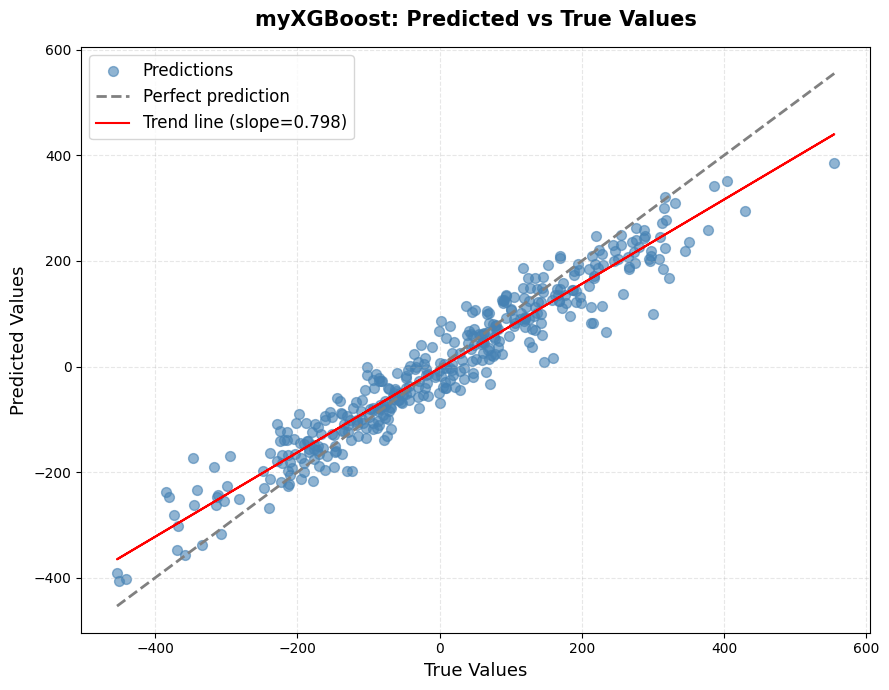

Correlation between true and predicted: 0.9627


In [9]:
# Create predicted vs true scatter plot
plt.figure(figsize=(9, 7))

# Plot predictions
plt.scatter(y_test, y_pred, alpha=0.6, s=50, label='Predictions', color='steelblue')

# Plot perfect prediction line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         '--', color='gray', linewidth=2, label='Perfect prediction')

# Add regression line
z = np.polyfit(y_test, y_pred, 1)
p = np.poly1d(z)
plt.plot(y_test, p(y_test), '-', color='red', linewidth=1.5, 
         label=f'Trend line (slope={z[0]:.3f})')

# Format plot
plt.xlabel('True Values', fontsize=13)
plt.ylabel('Predicted Values', fontsize=13)
plt.legend(fontsize=12, loc='upper left')
plt.title('myXGBoost: Predicted vs True Values', fontsize=15, pad=15, fontweight='bold')
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# Calculate correlation
correlation = np.corrcoef(y_test, y_pred)[0, 1]
print(f"Correlation between true and predicted: {correlation:.4f}")

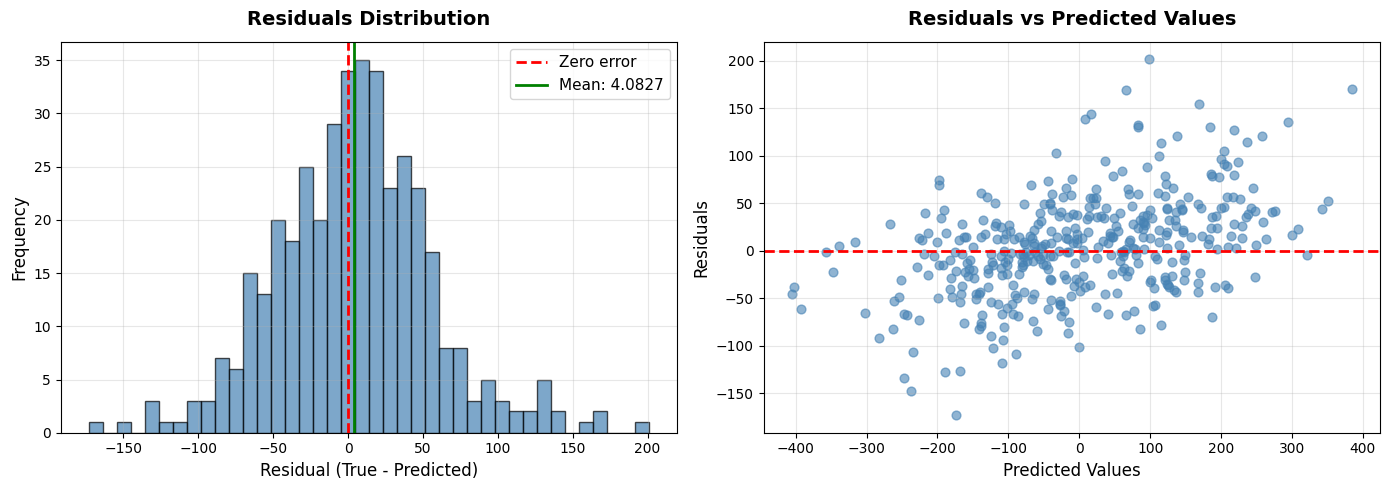

Residual Analysis:
----------------------------------------
Mean of residuals:     4.082714
Std Dev of residuals:  52.939866
Min residual:          -173.070179
Max residual:          201.123926

Percentage of residuals within ±1 std: 72.25%
Percentage of residuals within ±2 std: 94.25%


In [10]:
# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Calculate residuals
residuals = y_test - y_pred

# 1. Residuals histogram
axes[0].hist(residuals, bins=40, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero error')
axes[0].axvline(x=residuals.mean(), color='green', linestyle='-', linewidth=2, 
               label=f'Mean: {residuals.mean():.4f}')
axes[0].set_xlabel('Residual (True - Predicted)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Residuals Distribution', fontsize=14, pad=12, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# 2. Residuals vs Predicted values
axes[1].scatter(y_pred, residuals, alpha=0.6, s=40, color='steelblue')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Values', fontsize=12)
axes[1].set_ylabel('Residuals', fontsize=12)
axes[1].set_title('Residuals vs Predicted Values', fontsize=14, pad=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print residual statistics
print("Residual Analysis:")
print("-" * 40)
print(f"Mean of residuals:     {residuals.mean():.6f}")
print(f"Std Dev of residuals:  {residuals.std():.6f}")
print(f"Min residual:          {residuals.min():.6f}")
print(f"Max residual:          {residuals.max():.6f}")
print(f"\nPercentage of residuals within ±1 std: "
      f"{np.mean(np.abs(residuals) <= residuals.std()) * 100:.2f}%")
print(f"Percentage of residuals within ±2 std: "
      f"{np.mean(np.abs(residuals) <= 2 * residuals.std()) * 100:.2f}%")

In [11]:
# Check if feature_importances_ attribute exists
if hasattr(model, 'feature_importances_'):
    importances = model.feature_importances_
    
    if importances is not None and len(importances) > 0:
        plt.figure(figsize=(12, 7))
        
        # Sort importances
        indices = np.argsort(importances)[::-1]
        sorted_importances = importances[indices]
        feature_names = [f'Feature {i+1}' for i in range(len(importances))]
        sorted_features = [feature_names[i] for i in indices]
        
        # Create bar chart
        bars = plt.barh(range(len(importances)), sorted_importances, 
                       align='center', color='steelblue', alpha=0.8)
        
        # Add value labels on bars
        for i, (bar, val) in enumerate(zip(bars, sorted_importances)):
            width = bar.get_width()
            plt.text(width + 0.001, bar.get_y() + bar.get_height()/2, 
                    f'{val:.4f}', va='center', fontsize=9)
        
        plt.yticks(range(len(importances)), sorted_features, fontsize=11)
        plt.xlabel('Feature Importance', fontsize=13)
        plt.ylabel('Features', fontsize=13)
        plt.title('myXGBoost: Feature Importances', fontsize=15, pad=15, fontweight='bold')
        plt.grid(True, alpha=0.3, axis='x')
        plt.tight_layout()
        plt.show()
        
        # Print feature importance summary
        print("Top 10 Most Important Features:")
        print("-" * 40)
        total_importance = sum(sorted_importances)
        cumulative = 0
        for i in range(min(10, len(sorted_features))):
            importance_pct = sorted_importances[i] / total_importance * 100
            cumulative += importance_pct
            print(f"{i+1:2d}. {sorted_features[i]:15} "
                  f"{sorted_importances[i]:.6f} ({importance_pct:5.1f}%) "
                  f"[Cumulative: {cumulative:5.1f}%]")
        
        print(f"\nTotal features considered: {len(sorted_features)}")
        print(f"Sum of all importances: {total_importance:.6f}")
        
    else:
        print("Feature importances are None or empty.")
else:
    print("Feature importances attribute not found in the model.")

Feature importances attribute not found in the model.


In [12]:
# Check if staged_predict method exists for learning curve
if hasattr(model, 'staged_predict'):
    try:
        # Get predictions at each stage
        staged_preds = list(model.staged_predict(X_test))
        
        # Calculate metrics at each stage
        rmse_scores = [np.sqrt(mean_squared_error(y_test, pred)) 
                      for pred in staged_preds]
        r2_scores = [r2_score(y_test, pred) 
                    for pred in staged_preds]
        
        # Create figure with subplots
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # 1. RMSE over iterations
        axes[0].plot(range(1, len(rmse_scores) + 1), rmse_scores, 
                    marker='o', markersize=3, linewidth=1.5, color='steelblue')
        axes[0].set_xlabel('Number of Estimators', fontsize=12)
        axes[0].set_ylabel('RMSE', fontsize=12)
        axes[0].set_title('RMSE vs Number of Estimators', fontsize=14, pad=12, fontweight='bold')
        axes[0].grid(True, alpha=0.3)
        
        # Add best iteration marker
        best_rmse_iter = np.argmin(rmse_scores)
        axes[0].scatter(best_rmse_iter + 1, rmse_scores[best_rmse_iter], 
                       color='red', s=100, zorder=5, label=f'Best: iter {best_rmse_iter + 1}')
        axes[0].legend()
        
        # 2. R² score over iterations
        axes[1].plot(range(1, len(r2_scores) + 1), r2_scores, 
                    marker='s', markersize=3, linewidth=1.5, color='green')
        axes[1].set_xlabel('Number of Estimators', fontsize=12)
        axes[1].set_ylabel('R² Score', fontsize=12)
        axes[1].set_title('R² Score vs Number of Estimators', fontsize=14, pad=12, fontweight='bold')
        axes[1].grid(True, alpha=0.3)
        
        # Add best iteration marker
        best_r2_iter = np.argmax(r2_scores)
        axes[1].scatter(best_r2_iter + 1, r2_scores[best_r2_iter], 
                       color='red', s=100, zorder=5, label=f'Best: iter {best_r2_iter + 1}')
        axes[1].legend()
        
        plt.tight_layout()
        plt.show()
        
        # Print learning progress summary
        print("Learning Progress Summary:")
        print("-" * 40)
        print(f"Best RMSE: {rmse_scores[best_rmse_iter]:.4f} at iteration {best_rmse_iter + 1}")
        print(f"Best R²:   {r2_scores[best_r2_iter]:.4f} at iteration {best_r2_iter + 1}")
        
        # Check for convergence
        last_10_rmse = rmse_scores[-10:]
        rmse_change = (last_10_rmse[0] - last_10_rmse[-1]) / last_10_rmse[0] * 100
        print(f"\nLast 10 iterations RMSE change: {rmse_change:.3f}% improvement")
        
    except Exception as e:
        print(f"Could not generate learning curve: {e}")
else:
    print("staged_predict method not available for learning curve visualization.")

staged_predict method not available for learning curve visualization.


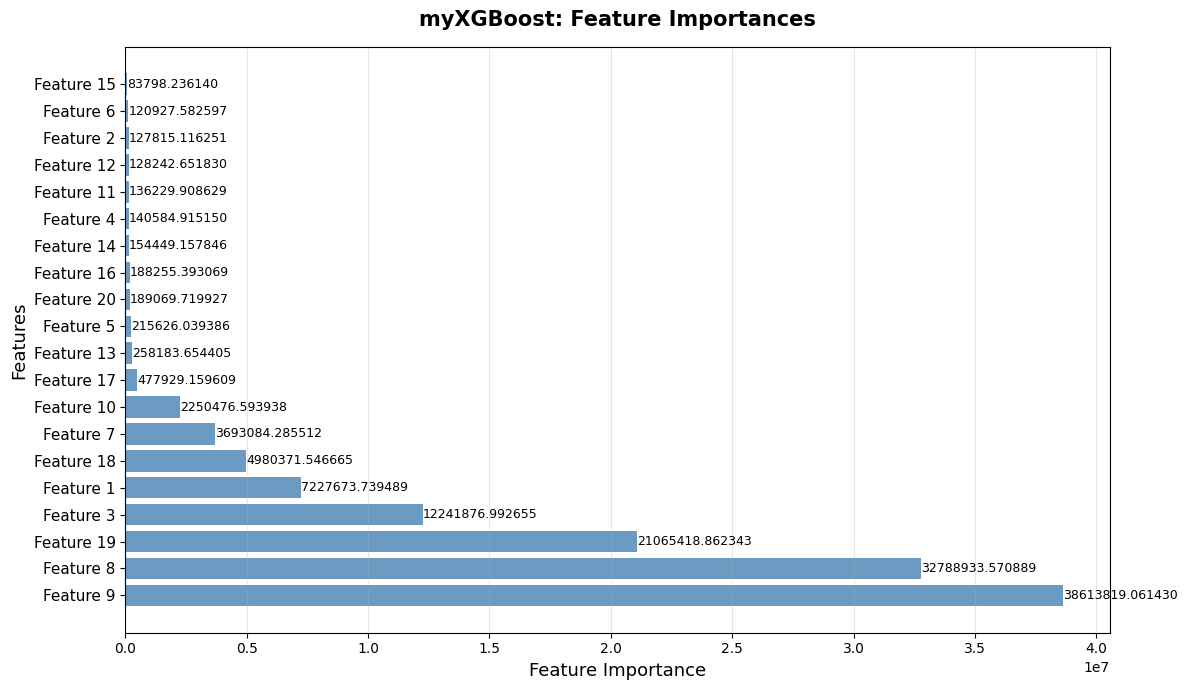

Top 10 Most Important Features:
----------------------------------------
 1. Feature 9       38613819.061430 ( 30.9%) [Cumulative:  30.9%]
 2. Feature 8       32788933.570889 ( 26.2%) [Cumulative:  57.1%]
 3. Feature 19      21065418.862343 ( 16.8%) [Cumulative:  73.9%]
 4. Feature 3       12241876.992655 (  9.8%) [Cumulative:  83.7%]
 5. Feature 1       7227673.739489 (  5.8%) [Cumulative:  89.5%]
 6. Feature 18      4980371.546665 (  4.0%) [Cumulative:  93.5%]
 7. Feature 7       3693084.285512 (  3.0%) [Cumulative:  96.4%]
 8. Feature 10      2250476.593938 (  1.8%) [Cumulative:  98.2%]
 9. Feature 17      477929.159609 (  0.4%) [Cumulative:  98.6%]
10. Feature 13      258183.654405 (  0.2%) [Cumulative:  98.8%]

Total features considered: 20
Sum of all importances: 125082766.187760


In [13]:
# Check if feature_importances_ attribute exists
importances = None

# First try: sklearn-style attribute
if hasattr(model, 'feature_importances_'):
    try:
        importances = np.asarray(model.feature_importances_)
    except Exception:
        importances = None

# Second try: myXGBoost booster-based computation for classification
if importances is None and hasattr(model, 'booster_'):
    try:
        from myXGBoost.utils.visualization import compute_feature_importance
        imp_dict = compute_feature_importance(model.booster_, importance_type='gain')
        # convert dict to array
        if imp_dict:
            n_feats = max(imp_dict.keys()) + 1
            importances = np.zeros(n_feats, dtype=float)
            for k, v in imp_dict.items():
                importances[k] = v
    except Exception:
        importances = None

# Third try: myXGBoost booster-based computation for regression
if importances is None and hasattr(model, 'booster_'):
    try:
        # For regression, we might need different approach
        from myXGBoost.utils.visualization import compute_feature_importance
        # Try 'weight' importance type for regression
        imp_dict = compute_feature_importance(model.booster_, importance_type='weight')
        if imp_dict:
            n_feats = max(imp_dict.keys()) + 1
            importances = np.zeros(n_feats, dtype=float)
            for k, v in imp_dict.items():
                importances[k] = v
    except Exception:
        importances = None

if importances is not None and importances.size > 0 and not np.all(np.isnan(importances)):
    plt.figure(figsize=(12, 7))
    
    # Sort importances
    indices = np.argsort(importances)[::-1]
    sorted_importances = importances[indices]
    feature_names = [f'Feature {i+1}' for i in range(len(importances))]
    sorted_features = [feature_names[i] for i in indices]
    
    # Create bar chart
    bars = plt.barh(range(len(importances)), sorted_importances, 
                   align='center', color='steelblue', alpha=0.8)
    
    # Add value labels on bars
    for i, (bar, val) in enumerate(zip(bars, sorted_importances)):
        width = bar.get_width()
        plt.text(width + (0.01 if width >= 0 else -0.01), bar.get_y() + bar.get_height()/2, 
                f'{val:.6f}', va='center', fontsize=9)
    
    plt.yticks(range(len(importances)), sorted_features, fontsize=11)
    plt.xlabel('Feature Importance', fontsize=13)
    plt.ylabel('Features', fontsize=13)
    plt.title('myXGBoost: Feature Importances', fontsize=15, pad=15, fontweight='bold')
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()
    
    # Print feature importance summary
    print("Top 10 Most Important Features:")
    print("-" * 40)
    total_importance = float(np.sum(sorted_importances)) if not math.isclose(np.sum(sorted_importances), 0.0) else 1.0
    cumulative = 0
    for i in range(min(10, len(sorted_features))):
        importance_pct = (sorted_importances[i] / total_importance) * 100
        cumulative += importance_pct
        print(f"{i+1:2d}. {sorted_features[i]:15} "
              f"{sorted_importances[i]:.6f} ({importance_pct:5.1f}%) "
              f"[Cumulative: {cumulative:5.1f}%]")
    
    print(f"\nTotal features considered: {len(sorted_features)}")
    print(f"Sum of all importances: {total_importance:.6f}")
    
else:
    print("Feature importances not available for this model.")

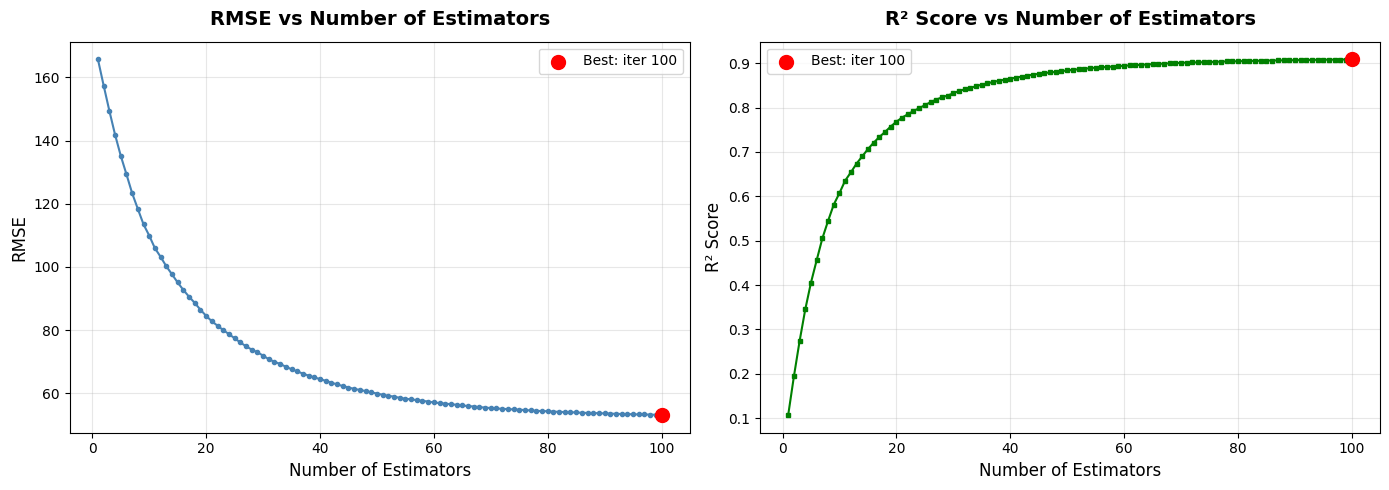

Learning Progress Summary:
----------------------------------------
Best RMSE: 53.0971 at iteration 100
Best R²:   0.9084 at iteration 100
Final RMSE: 53.0971
Final R²:   0.9084

Last 10 iterations RMSE change: 0.766% improvement


In [14]:
# Check if staged_predict method exists for learning curve
staged_preds = None

if hasattr(model, 'staged_predict'):
    try:
        staged_preds = list(model.staged_predict(X_test))
    except Exception as e:
        print(f"staged_predict failed: {e}")
        staged_preds = None

# Fallback: check if staged_predict_proba exists (for classification)
if staged_preds is None and hasattr(model, 'staged_predict_proba'):
    try:
        staged_proba = list(model.staged_predict_proba(X_test))
        # Convert probabilities to predictions (for regression, use the raw values)
        # For classification, this might need adjustment
        staged_preds = []
        for proba in staged_proba:
            if proba.ndim > 1:
                # Classification case - take positive class probability
                pred = proba[:, 1]  # Adjust based on your classification task
            else:
                # Could be regression probabilities or binary classification
                pred = proba
            staged_preds.append(pred)
    except Exception as e:
        print(f"staged_predict_proba failed: {e}")
        staged_preds = None

# Fallback: booster-based computation for myXGBoost
if staged_preds is None and hasattr(model, 'booster_'):
    try:
        booster = model.booster_
        n_trees = len(getattr(booster, 'trees', []))
        staged_preds = []
        
        # Determine if it's classification or regression
        # You might need to check model type or parameters
        is_classification = hasattr(model, 'classes_') or getattr(model, 'objective', '').startswith('binary')
        
        for k in range(1, n_trees + 1):
            raw = np.full(X_test.shape[0], getattr(booster, 'initial_prediction', 0.0), dtype=float)
            for i in range(k):
                raw += booster.learning_rate * booster.trees[i].predict(X_test)
            
            if is_classification:
                from myXGBoost.loss.classification import sigmoid
                pred = sigmoid(raw)
            else:
                pred = raw  # Regression
            
            staged_preds.append(pred)
    except Exception as e:
        print(f"Booster-based fallback failed: {e}")
        staged_preds = None

if staged_preds:
    try:
        # Calculate metrics at each stage
        rmse_scores = [np.sqrt(mean_squared_error(y_test, pred)) 
                      for pred in staged_preds]
        r2_scores = [r2_score(y_test, pred) 
                    for pred in staged_preds]
        
        # Create figure with subplots
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # 1. RMSE over iterations
        axes[0].plot(range(1, len(rmse_scores) + 1), rmse_scores, 
                    marker='o', markersize=3, linewidth=1.5, color='steelblue')
        axes[0].set_xlabel('Number of Estimators', fontsize=12)
        axes[0].set_ylabel('RMSE', fontsize=12)
        axes[0].set_title('RMSE vs Number of Estimators', fontsize=14, pad=12, fontweight='bold')
        axes[0].grid(True, alpha=0.3)
        
        # Add best iteration marker
        best_rmse_iter = int(np.argmin(rmse_scores))
        axes[0].scatter(best_rmse_iter + 1, rmse_scores[best_rmse_iter], 
                       color='red', s=100, zorder=5, label=f'Best: iter {best_rmse_iter + 1}')
        axes[0].legend()
        
        # 2. R² score over iterations
        axes[1].plot(range(1, len(r2_scores) + 1), r2_scores, 
                    marker='s', markersize=3, linewidth=1.5, color='green')
        axes[1].set_xlabel('Number of Estimators', fontsize=12)
        axes[1].set_ylabel('R² Score', fontsize=12)
        axes[1].set_title('R² Score vs Number of Estimators', fontsize=14, pad=12, fontweight='bold')
        axes[1].grid(True, alpha=0.3)
        
        # Add best iteration marker
        best_r2_iter = int(np.argmax(r2_scores))
        axes[1].scatter(best_r2_iter + 1, r2_scores[best_r2_iter], 
                       color='red', s=100, zorder=5, label=f'Best: iter {best_r2_iter + 1}')
        axes[1].legend()
        
        plt.tight_layout()
        plt.show()
        
        # Print learning progress summary
        print("Learning Progress Summary:")
        print("-" * 40)
        print(f"Best RMSE: {rmse_scores[best_rmse_iter]:.4f} at iteration {best_rmse_iter + 1}")
        print(f"Best R²:   {r2_scores[best_r2_iter]:.4f} at iteration {best_r2_iter + 1}")
        print(f"Final RMSE: {rmse_scores[-1]:.4f}")
        print(f"Final R²:   {r2_scores[-1]:.4f}")
        
        # Check for convergence
        if len(rmse_scores) >= 10:
            last_10_rmse = rmse_scores[-10:]
            rmse_change = (last_10_rmse[0] - last_10_rmse[-1]) / last_10_rmse[0] * 100
            print(f"\nLast 10 iterations RMSE change: {rmse_change:.3f}% improvement")
        
    except Exception as e:
        print(f"Could not generate learning curve: {e}")
else:
    print("Learning curve visualization not available for this model.")